# Unsupervised Machine Learning — Concepts

This notebook covers the core theory behind unsupervised learning, illustrated with small toy-data demos. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')           

sns.set_style('whitegrid')
# by using rcParams we write these settings once and every graph automatically uses it
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42                          
np.random.seed(RANDOM_STATE)                


## 1. Introduction to Unsupervised Learning

In unsupervised learning, the model is only given inputs X — there is no label/target y to learn from. Instead of comparing predictions to a known correct answer, the algorithm looks for structure that's already sitting inside the data itself: groups of similar points, or a smaller set of axes that still describe most of the variation.

## 2. Clustering vs Dimensionality Reduction

| | Clustering | Dimensionality Reduction |
|---|---|---|
| Definition | Groups similar data points together | Compresses many features into fewer ones while keeping the important structure |
| Example | grouping smartphone sensor readings by the physical activity that produced them | compressing hundreds of TF-IDF word-features into 2 for plotting |
| Typical algorithms | K-Means, Hierarchical, DBSCAN, GMM, Mean Shift | PCA, Kernel PCA, t-SNE, UMAP |
| Typical metrics | Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia | Explained variance, trustworthiness, downstream task performance |

The two are often used together: reduce dimensions first (e.g. PCA), then cluster or visualize the result.


## 3. Distance Metrics

A distance metric is needed in ML algorithms to understand how far apart or “dissimilar” two data items are in a given space

- **Euclidean distance** — straight-line distance; most common default; sensitive to feature scale.
- **Manhattan distance** — sum of absolute differences along each axis; less sensitive to outliers than Euclidean.
- **Cosine distance** — measures the angle between two vectors, ignoring magnitude; common for text/sparse data.
- **Mahalanobis distance** — like Euclidean, but adjusted for how features are correlated with each other.


In [2]:
from scipy.spatial import distance

# two points in 3D feature space
a = np.array([2, 4, 6])
b = np.array([1, 7, 3])

print('Euclidean :', distance.euclidean(a, b))   # straight-line distance
print('Manhattan :', distance.cityblock(a, b))    # sum of |differences|
print('Cosine    :', distance.cosine(a, b))       # 1 - cos(angle) between the vectors


Euclidean : 4.358898943540674
Manhattan : 7
Cosine    : 0.1649331992329348


## 4. Feature Scaling for Clustering

Distance-based algorithms (K-Means, Hierarchical, DBSCAN) treat every feature as equally important in whatever units it happens to be in. If one feature ranges 0-1000 and another ranges 0-1, the large-range feature will completely dominate the distance calculation.

`StandardScaler` (mean=0, std=1) is the usual fix


In [3]:
from sklearn.preprocessing import StandardScaler

toy = pd.DataFrame({
    'small_range': [1, 2, 3, 4, 5],
    'large_range': [1000, 1200, 900, 5000, 4800]
})
print('Before scaling:\n', toy.describe().loc[['mean', 'std']])

scaled = StandardScaler().fit_transform(toy)
print('\nAfter StandardScaler, both features now have mean ~0, std ~1:')
print(pd.DataFrame(scaled, columns=toy.columns).describe().loc[['mean', 'std']].round(2))


Before scaling:
       small_range  large_range
mean     3.000000  2580.000000
std      1.581139  2121.791696

After StandardScaler, both features now have mean ~0, std ~1:
      small_range  large_range
mean         0.00         0.00
std          1.12         1.12


## 5. Curse of Dimensionality
Website used: https://www.geeksforgeeks.org/machine-learning/curse-of-dimensionality-in-machine-learning/

Curse of Dimensionality refers to the phenomenon where the efficiency and effectiveness of algorithms deteriorate as the dimensionality of the data increases exponentially.
In high-dimensional spaces, data points become sparse, making it challenging to discern meaningful patterns or relationships due to the vast amount of data required to adequately sample the space.
Curse of Dimensionality leads to increased computational complexity, longer training times, and higher resource requirements in machine learning. Moreover, it escalates the risk of overfitting and spurious correlations, hindering the algorithms' ability to generalize well to unseen data.

[np.float64(0.9810883891801406), np.float64(1.1980199133005742), np.float64(1.234520492218302), np.float64(1.2224674409327005), np.float64(1.2373949429150235)]


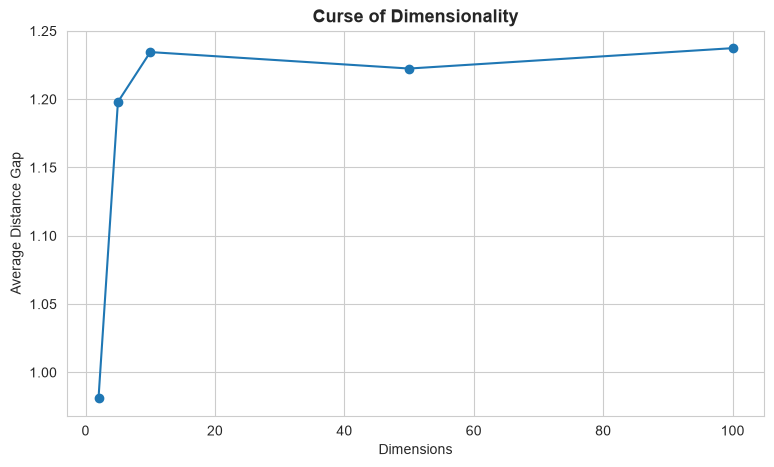

In [ ]:
from sklearn.metrics import pairwise_distances

dimensions = [2, 5, 10, 50, 100] # noof features we ll test
results = [] # store 1 ans for each dimension 

for d in dimensions:
    # generate 200 random points with d features
    points = np.random.rand(200, d) # erows n cols  bw 0 and 1 200 poins and ex 2 features
    # find the distance between every pair of points
    distances = pairwise_distances(points)
    nearest_distances = []
    farthest_distances = []
    # look at one point at a time
    for i in range(len(points)):
        # ignore distance from a point to itself
        distances[i][i] = np.inf
        # Smallest distance = nearest neighbor
        nearest = np.min(distances[i])
        # put self-distance back to 0
        distances[i][i] = 0
        # largest distance = farthest neighbor
        farthest = np.max(distances[i])

        nearest_distances.append(nearest)
        farthest_distances.append(farthest)
    average_gap = np.mean(farthest_distances) - np.mean(nearest_distances)
    results.append(average_gap)
print(results)
plt.plot(dimensions, results, marker='o')
plt.xlabel("Dimensions")
plt.ylabel("Average Distance Gap")
plt.title("Curse of Dimensionality")
plt.show()

## 6. Principal Component Analysis (PCA) 
Website : https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/ 

Reduces the number of features while trying to lose as little information(variance) as possible 

PCA uses linear algebra to transform data into new features called principal components. It finds these by calculating eigenvectors (directions) and eigenvalues (importance) from the covariance matrix. PCA selects the top components with the highest eigenvalues and projects the data onto them simplify the dataset.

It prioritizes the directions where the data varies the most because more variation = more useful information


In [ ]:
from sklearn.decomposition import PCA

rng = np.random.RandomState(RANDOM_STATE)
f1 = rng.normal(0, 1, 100) # mean std size 
f2 = rng.normal(0, 1, 100)
f3 = f1 * 0.9 + rng.normal(0, 0.1, 100)     # f3 is basically f1 + noise -> redundant/correlated doesnt contain much new info
pca_data = np.column_stack([f1, f2, f3]) # combines arrays into columns 

pca_demo = PCA(n_components=2).fit(pca_data) # reduce data to 2 features after 3 
print('Explained variance ratio per component:', pca_demo.explained_variance_ratio_.round(3)) # returns an array of two components 
print('-> first 2 components already capture', round(pca_demo.explained_variance_ratio_.sum()*100, 1), '% of the variance')


Explained variance ratio per component: [0.642 0.355]
-> first 2 components already capture 99.8 % of the variance


## 7. t-SNE vs UMAP

Both are **nonlinear** dimensionality reduction techniques mainly used for visualization, but they behave differently:

| | t-SNE | UMAP |
|---|---|---|
| Full-form | T-distributed Stochastic Neighbor Embedding | Uniform Manifold Approximation and Projection |
| What it preserves | Local neighborhood structure very well | Local structure well, and more global structure than t-SNE |
| Speed | Slower, doesn't scale well to large/high-dim data | Faster, scales better |
| New/unseen points | Cannot easily transform new points | Can transform new points once fitted |
| Global distances | Distances between far-apart clusters aren't very meaningful | Global distances are somewhat more meaningful |

**UMAP** faster, more general-purpose default

**t-SNE**  sharpest possible local-cluster separation for a one-off visualization and dataset size is manageable.


## 8. Cluster Validation Techniques

Reference - Stephanie Powers

Since unsupervised learning usually has no ground-truth labels, we need metrics that judge cluster quality directly from the data geometry:

- **Silhouette Score** (-1 to 1, higher better): looks at how far data points are from other clusters. If the silhouette score is close to 0 it means there are no meaningful clusters. If the score is closer to 1 the more the clusters are different from each other and finally if the score is closer to -1 then the datapoints are assigned to the wrong clusters.
- **Davies-Bouldin Index** (0+, lower better): average similarity between each cluster and its most-similar other cluster.
- **Calinski-Harabasz Index** (higher better): ratio of between-cluster dispersion to within-cluster dispersion.
- **Inertia** (lower better, K-Means only): sum of squared distances of points to their assigned cluster centroid — measures compactness, but always decreases as k grows, so it's mainly used via the "elbow method" rather than compared directly across different k.


In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=RANDOM_STATE)
labels = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit_predict(X)

print('Silhouette Score      :', round(silhouette_score(X, labels), 3), ' (higher is better)')
print('Davies-Bouldin Index  :', round(davies_bouldin_score(X, labels), 3), ' (lower is better)')
print('Calinski-Harabasz     :', round(calinski_harabasz_score(X, labels), 1), ' (higher is better)')
print('Inertia (K-Means)     :', round(KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X).inertia_, 1), ' (lower is better)')


Silhouette Score      : 0.878  (higher is better)
Davies-Bouldin Index  : 0.17  (lower is better)
Calinski-Harabasz     : 8087.4  (higher is better)
Inertia (K-Means)     : 362.8  (lower is better)
